In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf

In [58]:
# Define the fit function
def fit_func(x, a, b, wZ, x0):
    return (-a / 2) * (1 - erf(np.sqrt(2) * (x - x0) / wZ)) + b

# function to do fitting and plotting at the same time
def fit_and_plot(ax, x, y, title, color):
    # Initial parameter guess: a, b, wZ, x0
    p0 = [max(y) - min(y), min(y), np.mean(x), np.mean(x)]
    
    # Perform fit
    bounds = ([-np.inf, -np.inf, 1e-6, -np.inf], [np.inf, np.inf, np.inf, np.inf])
    popt, pcov = curve_fit(fit_func, x, y, p0=p0, bounds=bounds)
    
    # Plotting
    x_fit = np.linspace(min(x), max(x), 300)
    y_fit = fit_func(x_fit, *popt)

    ax.plot(x, y, 'o', color=color, label='Data')

    # Extract fitted wZ value and show
    wZ_value = popt[2]
    wZ_error = np.sqrt(np.diag(pcov))[2]  # Standard deviation (error) for wZ
    ax.text(0.95, 0.95, f'$w_Z = ({wZ_value:.2f} \\pm {wZ_error:.2f})$ μm', transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=12, color='black')

    # Actual plotting
    ax.plot(x_fit, y_fit, '-', color=color, label='Fit')
    ax.set_xlabel("x-position [μm]")
    ax.set_ylabel("Power")

    return popt, pcov

# File loading
def load_data(basepath, files, shift):
    dfs = []
    for i in range(2):
        df = pd.read_csv(f"{basepath}{files[i]}", skiprows=1, header=None)
        if i>0:
            df = df.iloc[1:, :].reset_index(drop=True)
            df[0] = df[0] + shift  # shift the first column for the second part of the measurement
        dfs.append(df)
    data = pd.concat(dfs, ignore_index=True)
    data.iloc[:, 1] *= 1000
    data = data.T.to_numpy()
    return data[0], data[1]

# File pairs I want to use
file_pairs = [
    ('close_01_Teil1.csv', 'close_01_Teil2.csv'),
    ('close_02_Teil1.csv', 'close_02_Teil2.csv'),
    ('close_03_Teil1.csv', 'close_03_Teil2.csv'),
    ('far_01_Teil1.csv', 'far_01_Teil2.csv'),
    ('far_02_Teil1.csv', 'far_02_Teil2.csv'),
    ('far_03_Teil1.csv', 'far_03_Teil2.csv')
]


Close measurements: wZ = (4556.78 ± 67.21) μm
Far measurements:   wZ = (4498.86 ± 75.35) μm


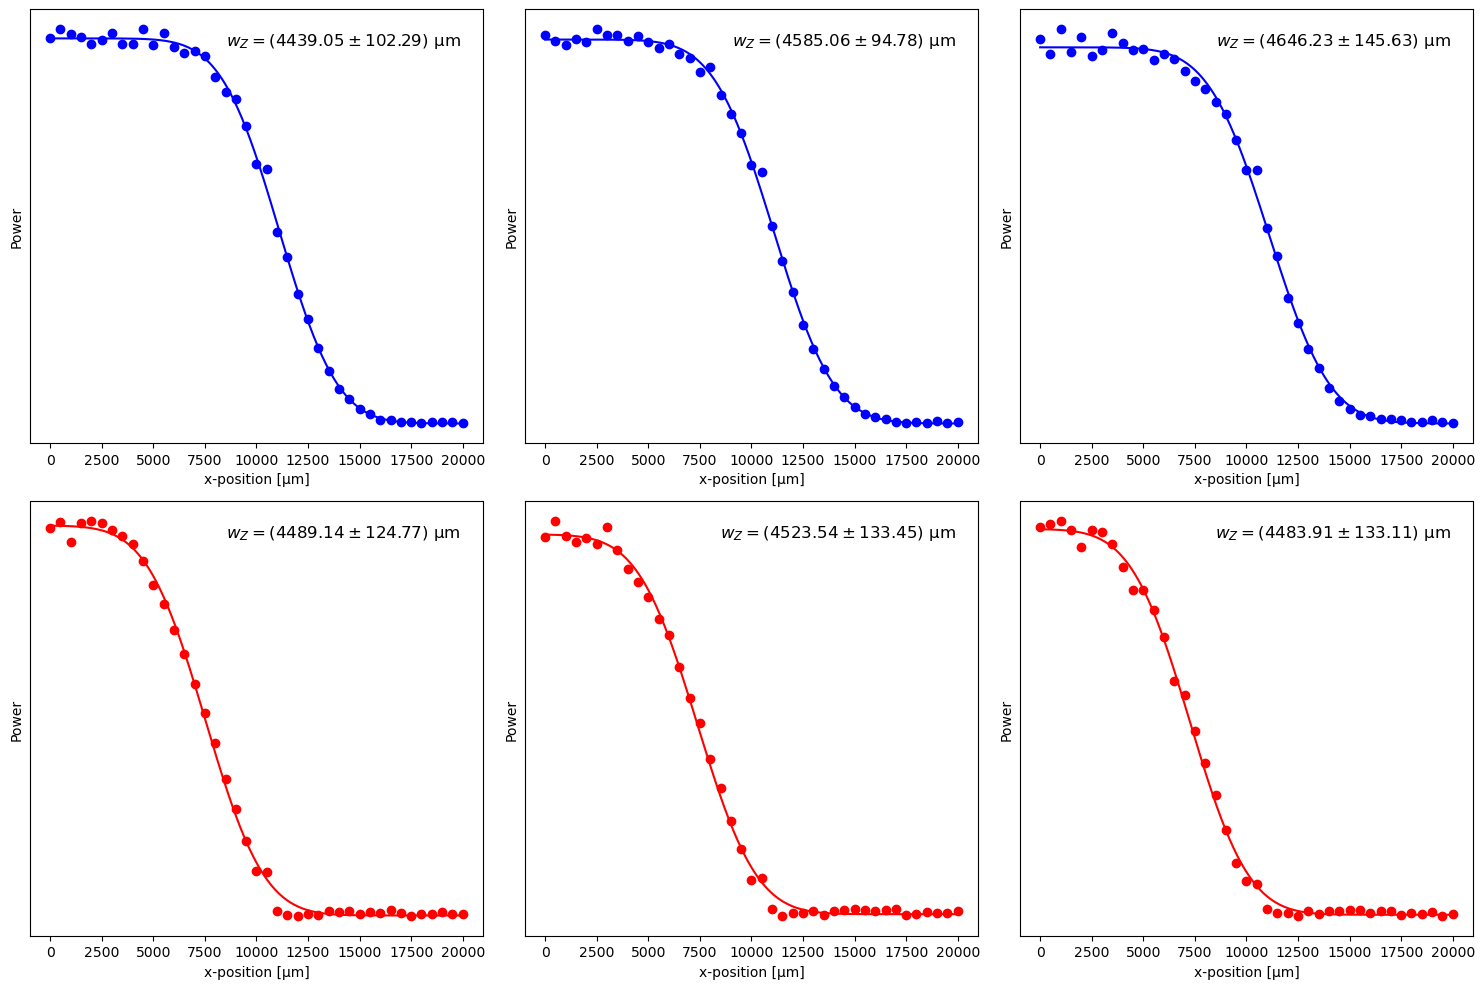

In [64]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  

# to save the wZ values and errors
wZ_values = []
wZ_errors = []

for i, (file1, file2) in enumerate(file_pairs):
    # Load data 
    positions, intensities = load_data('Data/', file_pairs[i], 10000)
    
    # Plot in corresponding subplot
    ax = axes[i]
    color = 'b' if i < 3 else 'r' # close measurements blue, far ones red
    
    # Fit and plot the data for this measurement
    popt, pcov = fit_and_plot(ax, positions, intensities, f'Measurement {i+1} - File 1', color)
    ax.set_yticks([])

    # Extract wZ & its error
    wZ = popt[2]
    wZ_err = np.sqrt(np.diag(pcov))[2]

    wZ_values.append(wZ)
    wZ_errors.append(wZ_err)


# for average diameter & error
def weighted_mean(values, errors):
    mean = np.mean(values)
    error = 1/3 * np.sqrt((errors[0]**2 + errors[1]**2 + errors[2]**2))    
    return mean, error

# --- Compute averages ---
wZ_close, wZ_close_err = weighted_mean(wZ_values[:3], wZ_errors[:3])
wZ_far, wZ_far_err = weighted_mean(wZ_values[3:], wZ_errors[3:])

# --- Print results ---
print(f"Close measurements: wZ = ({wZ_close:.2f} ± {wZ_close_err:.2f}) μm")
print(f"Far measurements:   wZ = ({wZ_far:.2f} ± {wZ_far_err:.2f}) μm")

# --- Adjust layout ---
plt.tight_layout()

# --- Show the plots ---
plt.show()